# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna 'edad' aparece como typo float requiere una transformacion a typo int.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
variables_numericas = df[['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']]
variables_numericas.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,15000.0,38.262400,11.492378,18.0,30.0000,38.000,46.0000,75.00
nivel_ingreso,15000.0,30019.704782,9833.166305,8000.0,23127.0975,30023.745,36768.4400,74790.84
visitas_mes,15000.0,10.029000,3.158189,1.0,8.0000,10.000,12.0000,25.00
compras_mes,15000.0,1.206467,1.105284,0.0,0.0000,1.000,2.0000,8.00
gasto_publicidad_dirigida,15000.0,20.149301,10.880724,0.0,12.3100,19.730,27.2925,75.51
satisfaccion,15000.0,3.603693,0.685300,1.0,3.1000,3.600,4.1000,5.00
ingreso_anual,15000.0,36.594180,34.484888,0.0,0.0000,30.705,58.2200,244.69


✍️ **Comentario**: 

Diagnóstico inicial de variables numéricas

- `edad` — La edad minima es de 18 años y la maxima es de 75 años.
- `nivel_ingreso` - El ingreso minimo es de 8,000 y el maximo es de 74,790.84. Se observa un aumento de mas del doble con referencia al 75% y la maxima, se recomienda analizar.
- `visitas_mes` - El rango de visitas es de 1 a 25.
- `compras_mes` - Existen clientes con 0 compras al mes. Se observa un aumento de mas del doble con referencia al 75% y a la maxima, aunque pueden ser posibles 8 compras mensuales.
- `gasto_publicidad_dirigida` - Se observa un aumento de mas del doble con referencia al 75% y la maxima, se recomienda analizar.
- `satisfaccion` - Tenemos un rango del 1 al 5.
- `ingreso_anual` - Se observan clientes con 0 compras en todo el año y un aumento abrupto del 75% a la maxima, se recomienda analizar.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
variables_binarias = df[['miembro_premium','abandono']]
print(variables_binarias.describe().T)
print(variables_binarias.nunique())
print(variables_binarias.value_counts('miembro_premium'))
print(variables_binarias.value_counts('abandono'))

                   count      mean       std  min  25%  50%  75%  max
miembro_premium  15000.0  0.139267  0.346236  0.0  0.0  0.0  0.0  1.0
abandono         15000.0  0.150733  0.357801  0.0  0.0  0.0  0.0  1.0
miembro_premium    2
abandono           2
dtype: int64
miembro_premium
0    12911
1     2089
dtype: int64
abandono
0    12739
1     2261
dtype: int64


✍️ **Comentario**: 

Diagnóstico inicial de variables binarias

- `miembro_premium` — Consta de 2 valores. Solo tenemos 2089 miembros premium.
- `abandono` — Consta de 2 valores. Solo 2261 han abandonado.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
variables_categoricas = df[['id_cliente','tipo_dispositivo','region']]
variables_categoricas.nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [9]:
# Explorar variables categóricas y cómo se distribuyen
variables_categoricas.describe()

,id_cliente,tipo_dispositivo,region
count,15000,15000,15000
unique,15000,3,4
top,CL-114451,móvil,norte
freq,1,9818,4395


✍️ **Comentario**: 

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Tiene 3 dispositivos diferentes, en los cuales destaca el movil con una frecuencia de 9818.
- `region` - Tiene 4 regiones, la que se repite mas veces es la norte con 4395 registros.
- `id_cliente` - Tiene 15000 clientes diferentes. 

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

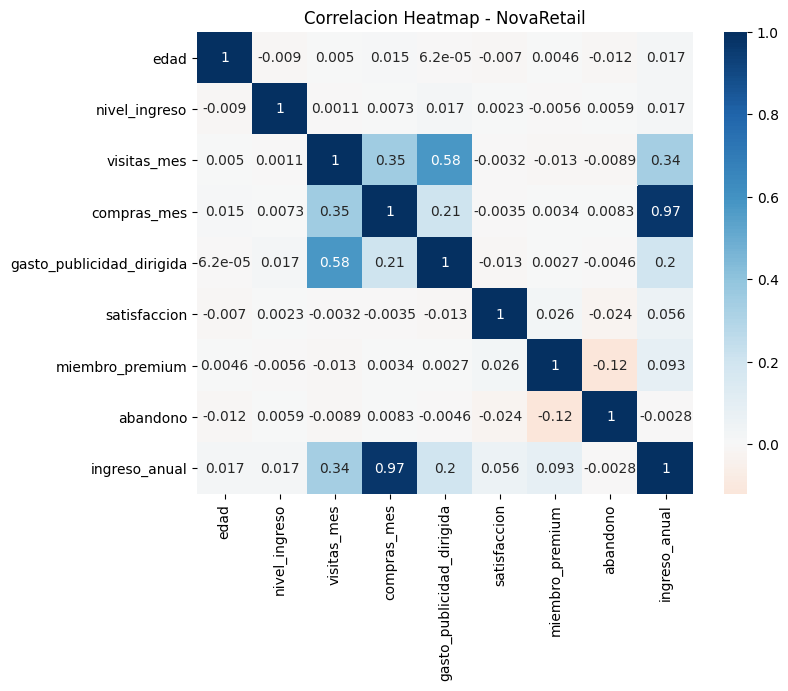

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu', center =0)
plt.title('Correlacion Heatmap - NovaRetail')
plt.show()

✍️ **Comentario**: 

Observaciones generales (Heatmap)  
- Se observa que las de mayor correlacion son: compras_mes/ingreso_anual con un 0.97 y visitas_mes/gasto_publicidad_dirigida con un 0.58.

Observaciones respecto a `ingreso_anual`  
- Presenta mayor correlacion con compras_mes, visitas_mes, gasto_publicidad_dirigida


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

### Scatterplot para pares clave

Text(0.5, 1.0, 'Compras al mes x Ingreso anual')

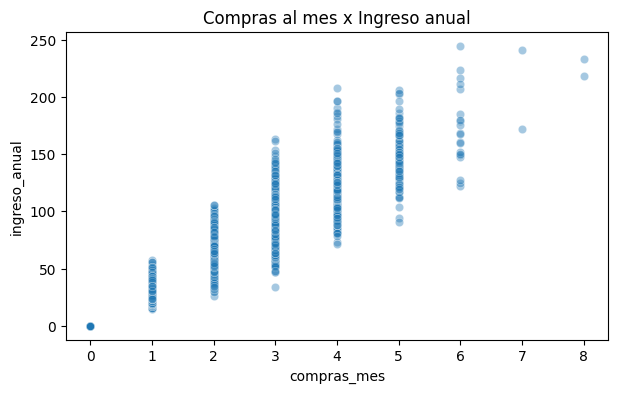

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes

plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.4)
plt.title('Compras al mes x Ingreso anual')


Text(0.5, 1.0, 'Visitas al mes x Ingreso anual')

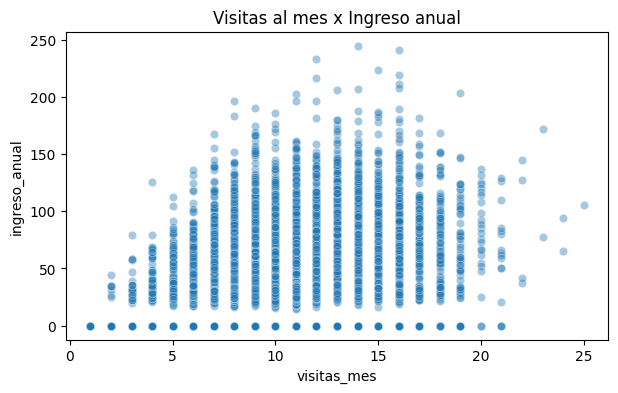

In [12]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', alpha=0.4)
plt.title('Visitas al mes x Ingreso anual')

✍️ **Comentario**: 

Observaciones iniciales (Scatterplot)

**Compras_mes vs Ingreso_anual**
- Dirección positiva y lineal, con poco outliers, dispersion baja y  colinealidad.
  
  

**Visitas_mes vs Ingreso_anual**
- Dirección positiva pero no tan fuerte no necesariamente mas visitas trae mas ingreso, tenemos una dispersion media, presencia de outliers y colinealidad media.
  

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
# Calcular correlación entre variables relevantes
corr_pearson = df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
corr_spearman = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')
print(f'Pearson', corr_pearson)
print(f'Spearman', corr_spearman)

Pearson 0.9671485435708564
Spearman 0.967482492032673


In [14]:
# Calcular correlación entre variables relevantes
corr_pearson = df['visitas_mes'].corr(df['ingreso_anual'], method='pearson')
corr_spearman = df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')
print(f'Pearson', corr_pearson)
print(f'Spearman', corr_spearman)

Pearson 0.3371466432498745
Spearman 0.32095369737696483


✍️ **Comentario**: 

Observaciones de correlación

**Ingreso_anual vs Compras_mes**
- Correlación ... alta
- Existe una relacion lineal y consistente entre ambas variables. Existe colinealidad.

**Ingreso_anual vs Visitas_mes**
- Correlación ... media
- Existe una direccion positiva aunque no tan fuerte, tambien existe consistencia media. Colinealidad media

### Punto-biserial

In [15]:
# Calcular correlación entre variables relevantes
print(pointbiserialr( df["miembro_premium"], df["ingreso_anual"] ))
print(pointbiserialr( df["abandono"], df["ingreso_anual"] ))

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)
SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)


✍️ **Comentario**: 

Observaciones Punto-biserial

**ingreso_anual vs miembro_premium**
- Relación ... Casi nula aunque ligeramente positiva con un 0.093

**ingreso_anual vs abandono**
- Relación ... Tenemos una direccion negativa y casi nula con un -0.002

### V de Cramér

In [25]:
# Función para calcular V de Cramér
def v_de_cramer(df, col1, col2):
    # df: es el dataframe.
    #col1 y col2 son las columnas a calcular v-de cramer.
    

    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    cramers_v

    print(f"La relación entre {col1} y {col2} es de: {cramers_v}")

    return cramers_v


In [31]:
# Aplicar V de Cramér en variables relevantes
cramer_1 = v_de_cramer(df, "abandono", "tipo_dispositivo")
cramer_2 = v_de_cramer(df, "abandono", "region")
cramer_3 = v_de_cramer(df, "abandono", "miembro_premium")
cramer_4 = v_de_cramer(df, "miembro_premium", "tipo_dispositivo")
cramer_5 = v_de_cramer(df, "miembro_premium", "region")
# abandono vs tipo_dispositivo
# abandono vs region
# abandono vs miembro_premium
# miembro_premium vs tipo_disposito
# miembro_premium vs region

La relación entre abandono y tipo_dispositivo es de: 0.007245190431994803
La relación entre abandono y region es de: 0.015429712175030079
La relación entre abandono y miembro_premium es de: 0.12021874609740511
La relación entre miembro_premium y tipo_dispositivo es de: 0.019725434455421662
La relación entre miembro_premium y region es de: 0.012574183027958333


✍️ **Comentario**: 

Observaciones V de Cramér

En la mayoria de las variables relevantes el resultado es cercado a cero lo que significa que no ahi correlacion entre ellas a diferencia de abandono vs miembro_premium que tiene un ligera correlacion positiva de 0.12, esto no quiere decir que su resultado cause directamente a la otra.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — 

**Evidencia visual:** Heatman y Scatterplot donde se muestra la correlacion con las variables numericas, las mas fuertes fueron compras_mes y visitas mes_ con relacion a ingreso_anual.

**Evidencia numérica:** 

Compras_mes / Ingreso_anual: Mostro un 0.97

Visitas_mes / Ingreso_anual: Mostro un 0.34 

**Interpretación**  
Compras_mes / Ingreso_anual: Significa que tiene un nivel alto de correlacion las compras del cliente cada mes con respecto al ingreso anual (Se podria decir que entre mas compra el cliente mas ingreso tiene NovaRetail).Existe una relacion lineal y consistente entre ambas variables. Existe colinealidad.

Visitas_mes / Ingreso_anual: Significa que tiene un nivel medio positivo de correlacion las visitas del cliente cada mes con respecto al ingreso anual.

**No podemos afirmar**  
No podemos afirmar que entre mas visitas hagan los clientes, mas van a comprar y asi generar mas ingresos anuales.

**Implicación de negocio**  
La correlación de 0.97 es extraordinariamente alta (casi una relación perfecta). Esto indica que el volumen de transacciones mensuales es el motor principal y directo de los ingresos de NovaRetail. La finalidad no debe ser solo que el cliente "venga", sino que "transaccione".
El negocio debe investigar por qué las visitas no se están transformando en compras. ¿Precios altos? ¿Falta de stock? ¿Proceso de pago complejo?

### Hallazgo 2 — 

**Evidencia visual:**  No aplica

**Evidencia numérica:** 

Miembros_Premium / Ingreso_anual: 0.093 

Abandono / Ingreso_anual: 0.0028

**Interpretación**  
Miembro_Premium / Ingreso_anual: En este caso la correlacion es de 0.093 aunque es positiva, es casi nula, lo que significaria que el ser que el tipo de miembro que sea el cliente no esta influyendo directamente al ingreso_anual.

Abandono / Ingreso_anual: En este caso la correlacion es de 0.0028 aunque es positiva, es aun mas nula que miembro_premium

**No podemos afirmar**  
Que si ahi mas clientes que se cambiaran al tipo de miembro premium, llegaria a afectar el ingreso_anual. Asi como tampoco podemos afirmar que si ahi menos abandono de clientes tambien subiria el ingreso_anual.

**Implicación de negocio**  
La correlación de 0.093 indica que no ahi suficientes clientes premium, se tendrai queu insentivar a los clientes a comvertirse a premium para ver si asi tenemos un aumento final. A su vez aunque son menos los clientes que abandondonan que los qeu se quedan , tendriamos que reducir aun mas ese nuemero he insentivar a que concluyan mas compras.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
  
Aunque al analizar el comportamiento en NovaRetail pudimos observar en sus datos que algunas variables tienen corracion positiva y otras correlacion negativa, no implica que los resultados de una, causen los resultados de otra.

En es caso de visitas_mes vs ingreso_anual su correlacion es positiva pero no quiere decir que entre mas visitas tengan mas ingresos a finales de año, no porque los clientes visiten mas van a comcluir una compra y con esto sus numeros de ingresos anuales aumenten. 

De igual manera con respecto a abandono vs ingreso_anual tienen una correlacion cercana a cero lo que podria resumirse en que no tiene casi nada que ver pero no podemos asumir que que si ahi mas o menos abandono cause una uamneto o disminucion en el ingreso a final de año.

### **Próximos pasos** 

Probar segmentación adicional
1) Segmentación por Valor y Comportamiento
Dado que compras_mes es la variable más fuerte, no todos los compradores son iguales. Divide a los usuarios en:
         -Usuarios con pocos clics pero tickets muy altos.
         -Cazadores de Ofertas: Alta correlación entre visitas_mes y eventos de descuento, pero baja con ingreso_anual.

2) Segmentación por "Lealtad Invisible"

   Miembro_premium tiene una correlación baja. Podrías segmentar por:
   -Antigüedad de la cuenta: A veces un usuario antiguo no es "Premium" pero gasta más que un miembro nuevo que solo se unió por una promoción.

3) Segmentación Geográfica y Tecnológica
   Poder adquisitivo regional: Segmentar por ciudades o zonas postales. Es posible que la correlación de visitas_mes suba en zonas urbanas con mayor acceso a logística rápida.

Dispositivo de acceso: Existe una correlación histórica en e-commerce entre usuarios de dispositivos de gama alta (iOS vs. Android de entrada) y el ingreso anual.